# Quantile Regression

Notebook to play around with quantile regression results, both the extremal and non-extremal cases.

In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xarray as xr
import pandas as pd
from pathlib import Path
import os
import seaborn as sns
import matplotlib.pyplot as plt

repo_dir = str(Path(os.getcwd()).parents[0])
os.chdir(repo_dir + '/scripts/')
from utils import display_catalog

In [2]:
# loading up the catalog
catalog = pd.read_hdf('~/extreme_antarctic_ARs/data/landfalling_storm_quantities_df.h5')

## Non-Extremal Quantile Regression

Following Koenker (2005).

,data_array,is_landfalling,max_area,mean_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,max_T2m_ais,avg_V10m_ais,max_V10m_ais,avg_V10m,max_V10m,avg_IWV_ais,max_IWV_ais,avg_IWV,max_IWV,landfalling_SLP,max_T2M_anomaly_ais,avg_vIVT_ais,max_vIVT_ais,avg_vIVT,max_vIVT,cumulative_rainfall_ais,cumulative_snowfall_ais
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,
2733,,True,1219813.707482,1188527.781133,567878.092915,141969.523229,0 days 06:00:00,1995-01-07 03:00:00,1995-01-07 06:00:00,-76.000000,274.629913,0.853522,8.889969,2.709316,10.033691,5.324115,14.543134,10.465161,20.789228,97207.593750,7.346375,56.887406,179.231766,138.832279,347.207367,102952232308.672241,1334106613365.135010
2734,,True,467035.576292,403237.485376,403237.485376,201618.742688,0 days 12:00:00,1995-01-08 21:00:00,1995-01-09 06:00:00,-79.000000,270.317108,-1.514148,4.896917,-1.514148,4.896917,2.303332,6.131917,2.303332,6.131917,100000000.000000,10.230209,13.987385,36.072113,13.987385,36.072113,1134.990017,797381048235.805908
2735,,True,964372.186669,795660.065030,58952.144193,29476.072097,0 days 12:00:00,1995-01-08 21:00:00,1995-01-09 06:00:00,-71.500000,272.077332,-3.792203,1.517767,8.508035,15.313753,7.438242,9.868498,12.381610,23.477619,96750.773438,1.650452,48.193964,96.928833,176.964111,377.114990,0.000000,308900595474.923523
2736,,True,824849.341249,685325.571848,54340.837391,20377.814022,0 days 12:00:00,1995-01-09 12:00:00,1995-01-09 21:00:00,-69.000000,269.943512,-8.400123,0.000000,7.713524,14.913183,6.269894,11.474287,18.774849,29.065453,97191.843750,0.218964,58.555097,102.934189,348.912328,645.732300,0.000000,806163282556.473145
2740,,True,2262846.280307,2112468.956708,105471.757808,118655.727534,1 days 03:00:00,1995-01-24 00:00:00,1995-01-25 00:00:00,-76.500000,279.203552,6.461016,19.237509,11.773177,21.582748,14.506771,25.030884,23.756501,39.180656,94993.968750,9.236847,263.376383,626.006409,494.445933,982.367371,1213744353811.588867,5222256982010.949219
2742,,True,469513.701565,469513.701565,20172.623139,2521.577892,0 days 03:00:00,1995-01-25 21:00:00,1995-01-25 21:00:00,-65.000000,276.087158,5.098894,6.599776,6.640935,9.521651,17.800580,21.750559,21.894893,26.320871,99274.132812,5.333679,222.883716,250.918503,308.667127,393.039001,53877883678.347076,105241602194.005798
2745,,True,2062531.498740,1946930.937618,1439336.157700,899585.098563,0 days 15:00:00,1995-01-31 09:00:00,1995-01-31 21:00:00,-84.500000,271.213379,-0.979768,6.798773,0.442153,13.414007,2.434042,15.231273,6.777173,30.128254,98089.898438,6.513290,24.511607,174.153442,104.314964,577.827881,0.000000,7796450810493.529297
2746,,True,13301.084608,13301.084608,13301.084608,1662.635576,0 days 03:00:00,1995-01-31 21:00:00,1995-01-31 21:00:00,-85.000000,257.919281,-1.265571,-0.000000,-1.265571,-0.000000,2.156281,2.621579,2.156281,2.621579,100000000.000000,2.744675,10.131580,11.890501,10.131580,11.890501,0.000000,4028211629.854589
2748,,True,864479.328599,605730.760761,85660.435996,85660.435996,1 days 06:00:00,1995-02-01 03:00:00,1995-02-02 06:00:00,-73.500000,268.417206,-1.776107,6.502579,10.341991,19.859102,4.974778,10.285123,23.054103,47.056141,97278.156250,7.982925,60.640733,164.887421,472.779351,1095.560669,0.000000,1676305541519.424072

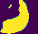
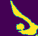

In [3]:
display_catalog(catalog, 10)

In [8]:
no_da = catalog.loc[:, catalog.columns != 'data_array']

In [12]:
no_da = no_da['duration']/pd.Timedelta(1, 'h')

In [13]:
no_da

cluster
2733.0     6.0
2734.0    12.0
2735.0    12.0
2736.0    12.0
2740.0    27.0
          ... 
7647.0    21.0
7652.0    42.0
7653.0    99.0
7655.0    15.0
7660.0    36.0
Name: duration, Length: 2998, dtype: float64

In [25]:
mod = smf.quantreg('cumulative_snowfall_ais ~ max_IWV_ais + cumulative_landfalling_area + max_south_extent + max_V10m_ais + landfalling_SLP', catalog)

In [28]:
res = mod.fit(q=0.99, max_iter=1000)

/global/homes/j/jbbutler/.conda/envs/antarctic_ars/lib/python3.12/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (10000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [30]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            QuantReg Regression Results                            
===================================================================================
Dep. Variable:     cumulative_snowfall_ais   Pseudo R-squared:               0.7327
Model:                            QuantReg   Bandwidth:                   9.246e+11
Method:                      Least Squares   Sparsity:                    3.983e+13
Date:                     Tue, 12 Nov 2024   No. Observations:                 2998
Time:                             17:30:38   Df Residuals:                     2992
                                             Df Model:                            5
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                    7.799e+08   1.32e+08      5.926      0.000    5.22e+08    1.04e+09
max_IWV_ais                  1.339e+10   3.51e+10      0.381      0.703   -5.55e+10    8.23e+10
cumulative_landfalling_area  1.669e+07   8.21e+04    203.198      0.000    1.65e+07    1.68e+07
max_south_extent            -5.181e+10   4.53e+09    -11.439      0.000   -6.07e+10   -4.29e+10
max_V10m_ais                 3.037e+10   1.41e+10      2.153      0.031    2.72e+09     5.8e+10
landfalling_SLP             -4.451e+04   2.96e+04     -1.503      0.133   -1.03e+05    1.35e+04
===============================================================================================

The condition number is large, 2.75e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Extremal Quantile Regression